In [1]:
# Data manipulation and analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load water quality training dataset
water_quality = pd.read_csv('../Provided Datasets/water_quality_training_dataset.csv')

print("Water Quality Dataset Info:")
print(f"Shape: {water_quality.shape}")
print(f"\nColumns: {list(water_quality.columns)}")
print(f"\nMissing values:")
print(water_quality[['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']].isnull().sum())

Water Quality Dataset Info:
Shape: (9319, 6)

Columns: ['Latitude', 'Longitude', 'Sample Date', 'Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']

Missing values:
Total Alkalinity                 0
Electrical Conductance           0
Dissolved Reactive Phosphorus    0
dtype: int64



TOTAL ALKALINITY
  Count: 9319
  Mean: 119.1082
  Median: 113.3000
  Std: 74.6926
  Min: 4.8000
  Max: 361.6760
  Skewness: 0.5361 (right-skewed)
  Kurtosis: -0.2529
  Mean-Median difference: 5.8082 (4.88% of mean)

DISSOLVED REACTIVE PHOSPHORUS
  Count: 9319
  Mean: 43.5253
  Median: 20.0000
  Std: 50.9802
  Min: 5.0000
  Max: 195.0000
  Skewness: 1.6444 (right-skewed)
  Kurtosis: 1.3324
  Mean-Median difference: 23.5253 (54.05% of mean)

ELECTRICAL CONDUCTANCE
  Count: 9319
  Mean: 485.0041
  Median: 402.0000
  Std: 341.9377
  Min: 15.1200
  Max: 1506.0000
  Skewness: 0.9293 (right-skewed)
  Kurtosis: 0.2893
  Mean-Median difference: 83.0041 (17.11% of mean)


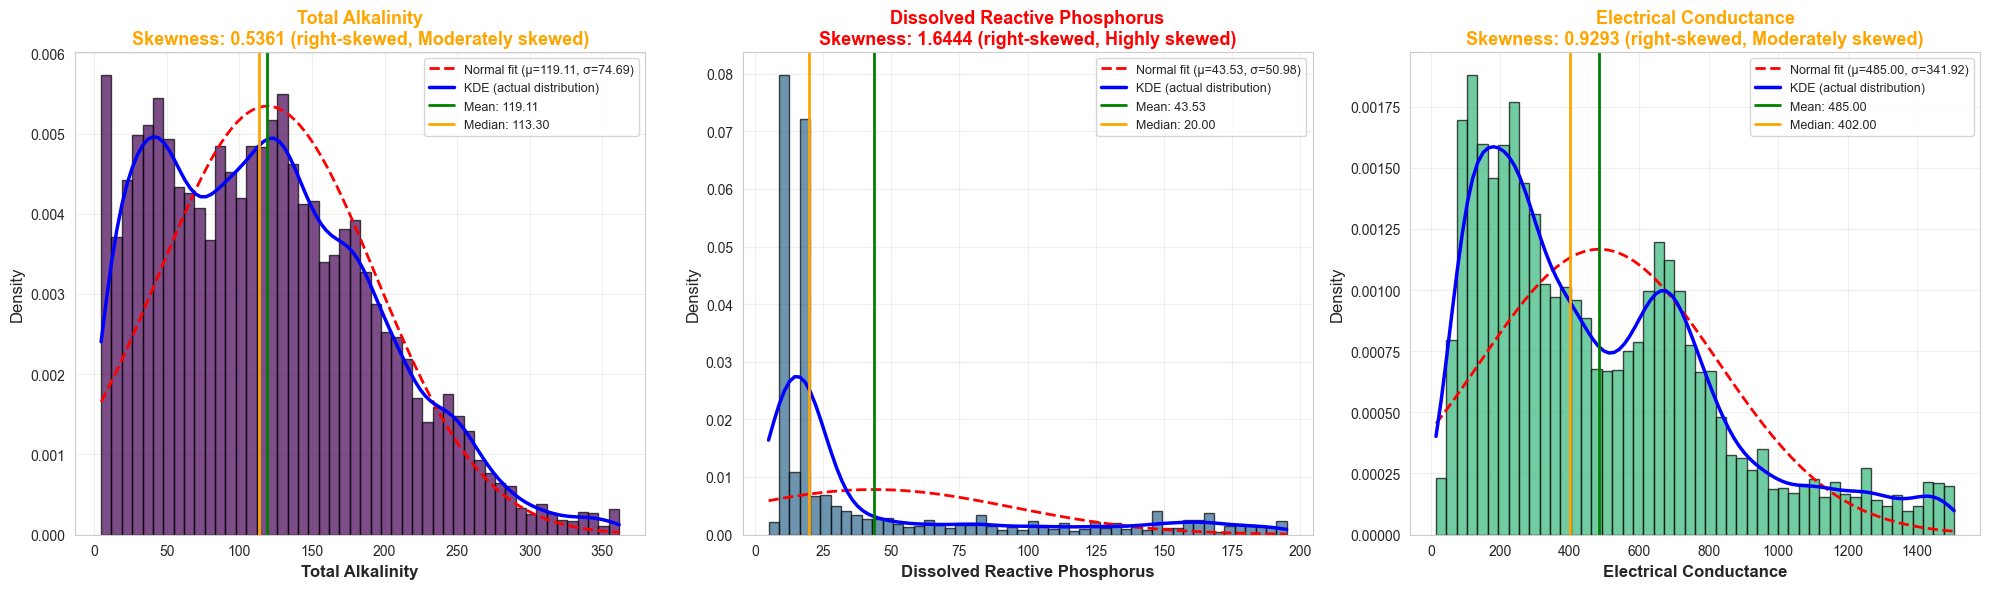


SUMMARY COMPARISON

                       Feature Skewness Kurtosis   Mean Median    Std
             Total Alkalinity   0.5361  -0.2529 119.11 113.30  74.69
Dissolved Reactive Phosphorus   1.6444   1.3324  43.53  20.00  50.98
       Electrical Conductance   0.9293   0.2893 485.00 402.00 341.94

Note: Positive skewness = right tail, Negative skewness = left tail


In [3]:
# Create histograms with skewness curves for each feature

# Features to analyze
features = {
    'Total Alkalinity': 'Total Alkalinity',
    'Dissolved Reactive Phosphorus': 'Dissolved Reactive Phosphorus',
    'Electrical Conductance': 'Electrical Conductance'
}

# Create figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (feature_name, column_name) in enumerate(features.items()):
    # Get data, removing missing values
    data = water_quality[column_name].dropna()
    
    # Calculate skewness
    skewness = stats.skew(data)
    
    # Create histogram
    n, bins, patches = axes[idx].hist(data, bins=50, density=True, alpha=0.7, 
                                      edgecolor='black', color=plt.cm.viridis(idx/3))
    
    # Fit a normal distribution to the data for comparison
    mu, sigma = stats.norm.fit(data)
    x = np.linspace(data.min(), data.max(), 100)
    normal_curve = stats.norm.pdf(x, mu, sigma)
    
    # Plot normal distribution curve
    axes[idx].plot(x, normal_curve, 'r--', linewidth=2, label=f'Normal fit (μ={mu:.2f}, σ={sigma:.2f})')
    
    # Create a kernel density estimate (KDE) curve to show actual distribution shape
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    kde_x = np.linspace(data.min(), data.max(), 100)
    kde_curve = kde(kde_x)
    axes[idx].plot(kde_x, kde_curve, 'b-', linewidth=2.5, label='KDE (actual distribution)')
    
    # Add mean and median lines
    mean_val = data.mean()
    median_val = data.median()
    axes[idx].axvline(mean_val, color='green', linestyle='-', linewidth=2, 
                      label=f'Mean: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='orange', linestyle='-', linewidth=2, 
                      label=f'Median: {median_val:.2f}')
    
    # Customize plot
    axes[idx].set_xlabel(feature_name, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Density', fontsize=12)
    
    # Determine skewness interpretation
    if abs(skewness) < 0.5:
        skew_interpretation = "≈ Symmetric"
        color = 'green'
    elif abs(skewness) < 1:
        skew_interpretation = "Moderately skewed"
        color = 'orange'
    else:
        skew_interpretation = "Highly skewed"
        color = 'red'
    
    direction = "right" if skewness > 0 else "left"
    title = f'{feature_name}\nSkewness: {skewness:.4f} ({direction}-skewed, {skew_interpretation})'
    axes[idx].set_title(title, fontsize=13, fontweight='bold', color=color)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9, loc='best')
    
    # Print statistics
    print(f"\n{'='*70}")
    print(f"{feature_name.upper()}")
    print(f"{'='*70}")
    print(f"  Count: {len(data)}")
    print(f"  Mean: {mean_val:.4f}")
    print(f"  Median: {median_val:.4f}")
    print(f"  Std: {data.std():.4f}")
    print(f"  Min: {data.min():.4f}")
    print(f"  Max: {data.max():.4f}")
    print(f"  Skewness: {skewness:.4f} ({direction}-skewed)")
    print(f"  Kurtosis: {stats.kurtosis(data):.4f}")
    if abs(mean_val - median_val) > 0.01 * mean_val:
        print(f"  Mean-Median difference: {abs(mean_val - median_val):.4f} "
              f"({abs(mean_val - median_val)/mean_val*100:.2f}% of mean)")

plt.tight_layout()
plt.show()

# Summary comparison
print("\n" + "="*70)
print("SUMMARY COMPARISON")
print("="*70)
summary_data = []
for feature_name, column_name in features.items():
    data = water_quality[column_name].dropna()
    summary_data.append({
        'Feature': feature_name,
        'Skewness': f"{stats.skew(data):.4f}",
        'Kurtosis': f"{stats.kurtosis(data):.4f}",
        'Mean': f"{data.mean():.2f}",
        'Median': f"{data.median():.2f}",
        'Std': f"{data.std():.2f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))
print("\nNote: Positive skewness = right tail, Negative skewness = left tail")


Total Alkalinity:
  Total samples: 9319
  Latitude range: [-34.41, -22.23]
  Longitude range: [17.73, 32.33]
  Feature range: [4.80, 361.68]
  Mean Total Alkalinity: 119.11

Dissolved Reactive Phosphorus:
  Total samples: 9319
  Latitude range: [-34.41, -22.23]
  Longitude range: [17.73, 32.33]
  Feature range: [5.00, 195.00]
  Mean Dissolved Reactive Phosphorus: 43.53

Electrical Conductance:
  Total samples: 9319
  Latitude range: [-34.41, -22.23]
  Longitude range: [17.73, 32.33]
  Feature range: [15.12, 1506.00]
  Mean Electrical Conductance: 485.00


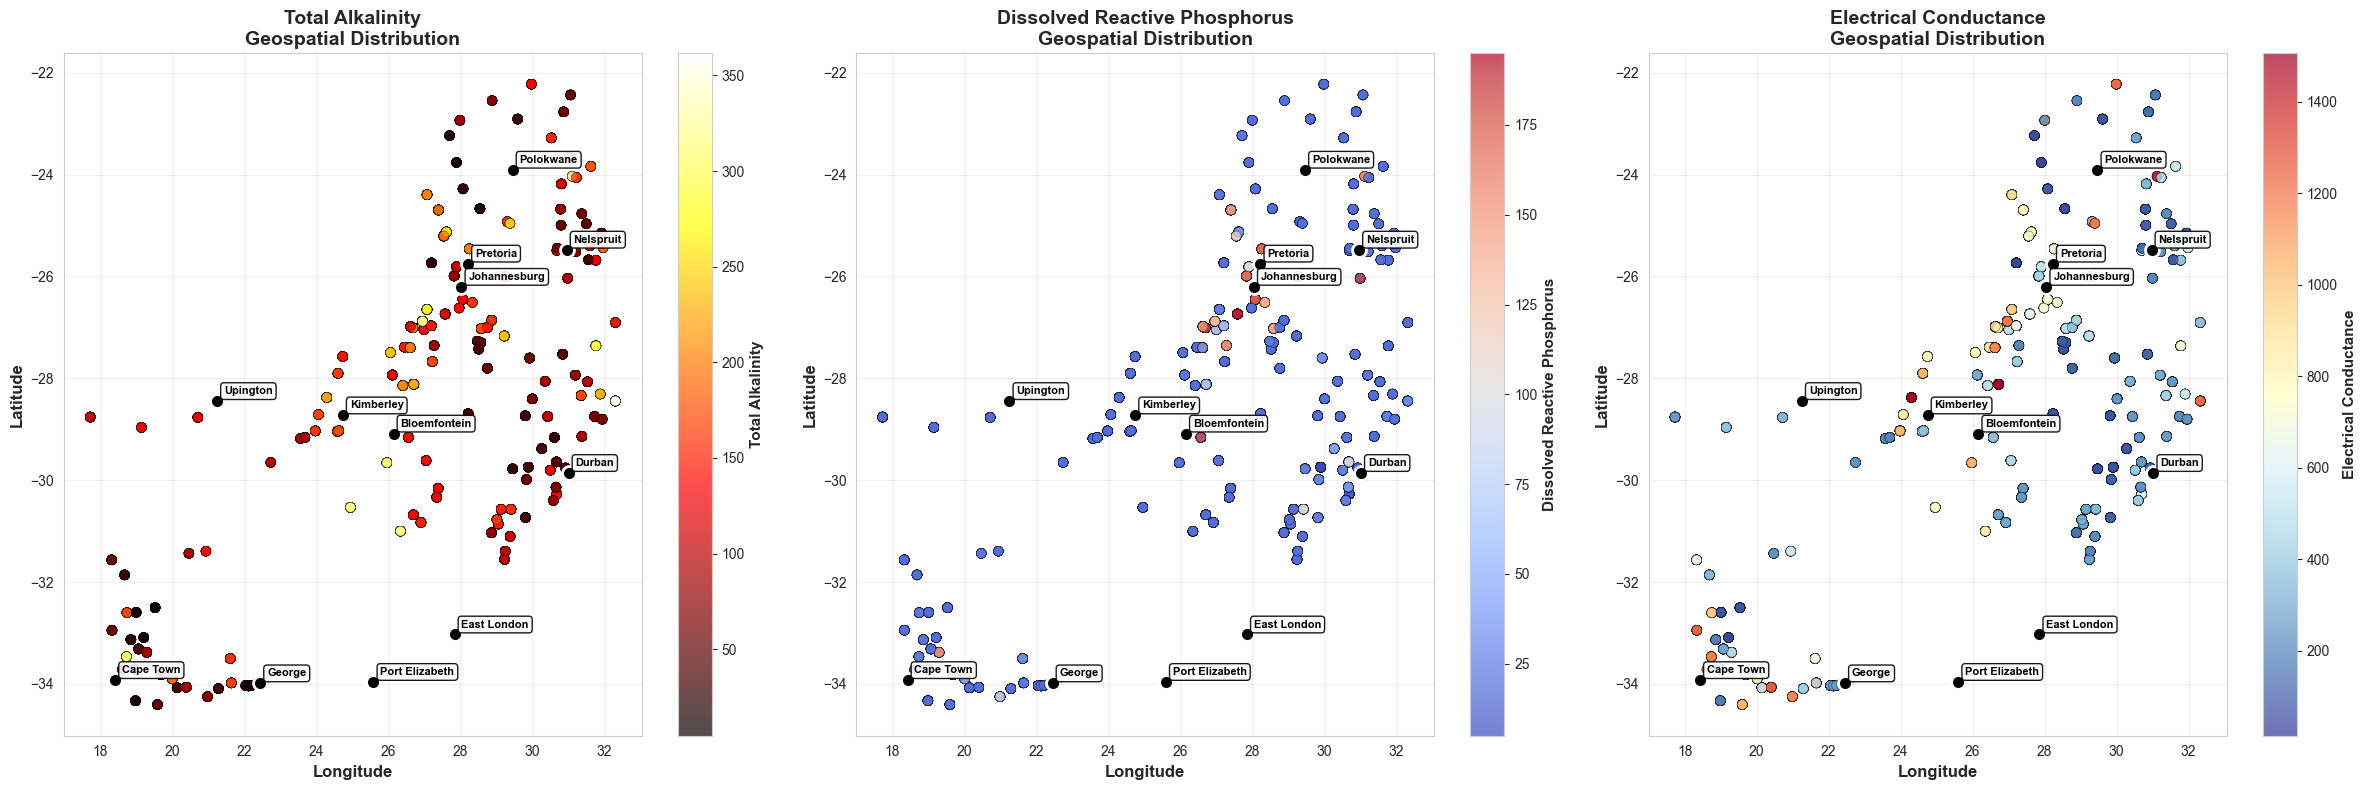


Geospatial heat maps created successfully!


In [5]:
# Create scatterplot geospatial heat maps for the three water quality features

# Clean data - remove rows with missing coordinates or feature values
water_quality_clean = water_quality.dropna(subset=['Latitude', 'Longitude'])

# Define prominent South African cities with their coordinates
south_african_cities = {
    'Cape Town': [-33.9249, 18.4241],
    'Johannesburg': [-26.2041, 28.0473],
    'Durban': [-29.8587, 31.0218],
    'Pretoria': [-25.7479, 28.2293],
    'Port Elizabeth': [-33.9608, 25.6022],
    'Bloemfontein': [-29.0852, 26.1596],
    'East London': [-33.0292, 27.8546],
    'Polokwane': [-23.9045, 29.4689],
    'Nelspruit': [-25.4745, 30.9703],
    'Kimberley': [-28.7282, 24.7497],
    'George': [-33.9881, 22.4536],
    'Upington': [-28.4478, 21.2561]
}

# Features to visualize
features = {
    'Total Alkalinity': 'Total Alkalinity',
    'Dissolved Reactive Phosphorus': 'Dissolved Reactive Phosphorus',
    'Electrical Conductance': 'Electrical Conductance'
}

# Create figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Color maps for each feature - using high contrast colormaps
colormaps = ['hot', 'coolwarm', 'RdYlBu_r']

for idx, (feature_name, column_name) in enumerate(features.items()):
    # Get data with valid coordinates and feature values
    plot_data = water_quality_clean.dropna(subset=[column_name])
    
    # Create scatter plot colored by feature values - larger dots with better contrast
    scatter = axes[idx].scatter(plot_data['Longitude'], 
                                plot_data['Latitude'], 
                                c=plot_data[column_name], 
                                cmap=colormaps[idx], 
                                s=50, 
                                alpha=0.7, 
                                edgecolors='black',
                                linewidths=0.3)
    
    # Add city markers - make them more visible
    for city_name, (lat, lon) in south_african_cities.items():
        axes[idx].plot(lon, lat, 'ko', markersize=10, markeredgecolor='white', markeredgewidth=2)
        axes[idx].annotate(city_name, (lon, lat), xytext=(5, 5), textcoords='offset points', 
                          fontsize=8, fontweight='bold', color='black',
                          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='black'))
    
    # Customize plot
    axes[idx].set_xlabel('Longitude', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Latitude', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{feature_name}\nGeospatial Distribution', fontsize=14, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=axes[idx])
    cbar.set_label(feature_name, fontsize=11, fontweight='bold')
    
    # Print statistics
    print(f"\n{feature_name}:")
    print(f"  Total samples: {len(plot_data)}")
    print(f"  Latitude range: [{plot_data['Latitude'].min():.2f}, {plot_data['Latitude'].max():.2f}]")
    print(f"  Longitude range: [{plot_data['Longitude'].min():.2f}, {plot_data['Longitude'].max():.2f}]")
    print(f"  Feature range: [{plot_data[column_name].min():.2f}, {plot_data[column_name].max():.2f}]")
    print(f"  Mean {feature_name}: {plot_data[column_name].mean():.2f}")

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Geospatial heat maps created successfully!")
print("="*70)

In [ ]:
# Overlay population density with geospatial distributions

# Clean data - remove rows with missing coordinates or feature values
water_quality_clean = water_quality.dropna(subset=['Latitude', 'Longitude'])

# Define prominent South African cities with their coordinates and approximate population
# Population data helps create a density proxy
south_african_cities = {
    'Cape Town': {'coords': [-33.9249, 18.4241], 'pop': 4.6e6},
    'Johannesburg': {'coords': [-26.2041, 28.0473], 'pop': 5.6e6},
    'Durban': {'coords': [-29.8587, 31.0218], 'pop': 3.1e6},
    'Pretoria': {'coords': [-25.7479, 28.2293], 'pop': 2.5e6},
    'Port Elizabeth': {'coords': [-33.9608, 25.6022], 'pop': 1.2e6},
    'Bloemfontein': {'coords': [-29.0852, 26.1596], 'pop': 0.5e6},
    'East London': {'coords': [-33.0292, 27.8546], 'pop': 0.8e6},
    'Polokwane': {'coords': [-23.9045, 29.4689], 'pop': 0.6e6},
    'Nelspruit': {'coords': [-25.4745, 30.9703], 'pop': 0.4e6},
    'Kimberley': {'coords': [-28.7282, 24.7497], 'pop': 0.3e6},
    'George': {'coords': [-33.9881, 22.4536], 'pop': 0.2e6},
    'Upington': {'coords': [-28.4478, 21.2561], 'pop': 0.1e6}
}

# Create a population density proxy based on distance from major cities
def calculate_population_density_proxy(lat, lon, cities_dict):
    """Calculate population density proxy based on inverse distance weighting from cities"""
    total_density = 0
    for city_name, city_info in cities_dict.items():
        city_lat, city_lon = city_info['coords']
        city_pop = city_info['pop']
        
        # Calculate distance (simplified Euclidean distance in degrees)
        # For more accuracy, could use Haversine formula
        distance = np.sqrt((lat - city_lat)**2 + (lon - city_lon)**2)
        
        # Inverse distance weighting - closer cities contribute more
        # Add small epsilon to avoid division by zero
        weight = city_pop / (distance + 0.01)
        total_density += weight
    
    return total_density

# Calculate population density proxy for all data points
print("Calculating population density proxy...")
water_quality_clean['pop_density_proxy'] = water_quality_clean.apply(
    lambda row: calculate_population_density_proxy(row['Latitude'], row['Longitude'], south_african_cities),
    axis=1
)

# Features to visualize
features = {
    'Total Alkalinity': 'Total Alkalinity',
    'Dissolved Reactive Phosphorus': 'Dissolved Reactive Phosphorus',
    'Electrical Conductance': 'Electrical Conductance'
}

# Create figure with subplots - showing population density as background
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Color maps for each feature - using high contrast colormaps
colormaps = ['hot', 'coolwarm', 'RdYlBu_r']

for idx, (feature_name, column_name) in enumerate(features.items()):
    # Get data with valid coordinates and feature values
    plot_data = water_quality_clean.dropna(subset=[column_name])
    
    # First, create a hexbin plot showing population density as background
    # This creates a density heatmap
    hexbin_pop = axes[idx].hexbin(plot_data['Longitude'], 
                                   plot_data['Latitude'], 
                                   C=plot_data['pop_density_proxy'],
                                   gridsize=30, 
                                   cmap='Greys', 
                                   alpha=0.4, 
                                   mincnt=1,
                                   reduce_C_function=np.mean)
    
    # Overlay scatter plot colored by feature values - larger dots with better contrast
    scatter = axes[idx].scatter(plot_data['Longitude'], 
                                plot_data['Latitude'], 
                                c=plot_data[column_name], 
                                cmap=colormaps[idx], 
                                s=50, 
                                alpha=0.7, 
                                edgecolors='black',
                                linewidths=0.3,
                                zorder=5)  # Ensure scatter is on top
    
    # Add city markers - make them more visible
    for city_name, city_info in south_african_cities.items():
        lat, lon = city_info['coords']
        pop = city_info['pop']
        # Size marker based on population
        marker_size = 8 + (pop / 1e6) * 2
        axes[idx].plot(lon, lat, 'ko', markersize=marker_size, 
                      markeredgecolor='white', markeredgewidth=2, zorder=10)
        axes[idx].annotate(city_name, (lon, lat), xytext=(5, 5), 
                          textcoords='offset points', 
                          fontsize=8, fontweight='bold', color='black',
                          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                                  alpha=0.9, edgecolor='black'),
                          zorder=10)
    
    # Customize plot
    axes[idx].set_xlabel('Longitude', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Latitude', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{feature_name}\nGeospatial Distribution (Population Density Overlay)', 
                        fontsize=14, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Add colorbar for the feature
    cbar = plt.colorbar(scatter, ax=axes[idx])
    cbar.set_label(feature_name, fontsize=11, fontweight='bold')
    
    # Print statistics
    print(f"\n{feature_name}:")
    print(f"  Total samples: {len(plot_data)}")
    print(f"  Feature range: [{plot_data[column_name].min():.2f}, {plot_data[column_name].max():.2f}]")
    print(f"  Mean {feature_name}: {plot_data[column_name].mean():.2f}")

plt.tight_layout()
plt.show()

# Create a separate figure showing just population density for reference
fig2, ax = plt.subplots(1, 1, figsize=(12, 10))

# Create hexbin showing population density
hexbin = ax.hexbin(water_quality_clean['Longitude'], 
                   water_quality_clean['Latitude'], 
                   C=water_quality_clean['pop_density_proxy'],
                   gridsize=40, 
                   cmap='YlOrRd', 
                   mincnt=1,
                   reduce_C_function=np.mean)

# Add city markers
for city_name, city_info in south_african_cities.items():
    lat, lon = city_info['coords']
    pop = city_info['pop']
    marker_size = 10 + (pop / 1e6) * 3
    ax.plot(lon, lat, 'ko', markersize=marker_size, 
           markeredgecolor='white', markeredgewidth=2)
    ax.annotate(city_name, (lon, lat), xytext=(5, 5), 
               textcoords='offset points', 
               fontsize=9, fontweight='bold', color='black',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                       alpha=0.9, edgecolor='black'))

ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
ax.set_title('South Africa Population Density Proxy\n(Based on Distance from Major Cities)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

cbar2 = plt.colorbar(hexbin, ax=ax)
cbar2.set_label('Population Density Proxy (weighted by city proximity)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Population density overlay created successfully!")
print("="*70)
print("\nNote: Population density is estimated using inverse distance weighting")
print("from major South African cities. Darker areas indicate higher population density.")
print("Water quality samples are overlaid on top, colored by feature values.")